In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
from graphviz import Digraph

%matplotlib inline

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

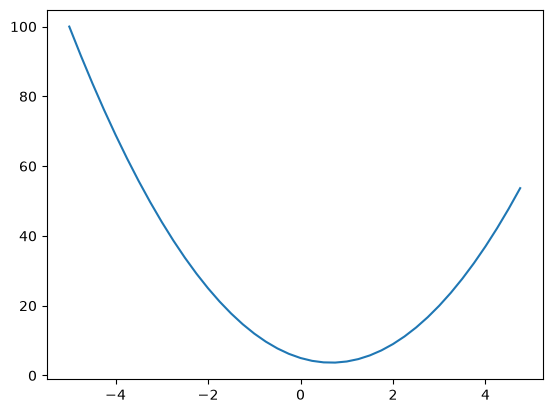

In [6]:
plt.plot(xs, ys)

In [7]:
h = 0.0000001
x = 2/3
(f(x+h) - f(x)) / h

2.9753977059954195e-07

In [8]:
a = 2.0
b = -3.0
c = 10.0

d = a*b + c
d

4.0

In [9]:
h = 0.000001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.000002
slope 2.000000000279556


In [10]:
class Value:
    def __init__(self, data, _children=(), op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        other  = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __mul__(self, other):
        other  = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
    
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
    
        return out

    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # self - other
        return self.__sub__(other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - (t ** 2)) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        t = math.exp(x)
        out = Value(t, (self, ), 'exp')

        def _backward():
            self.grad += t * out.grad
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

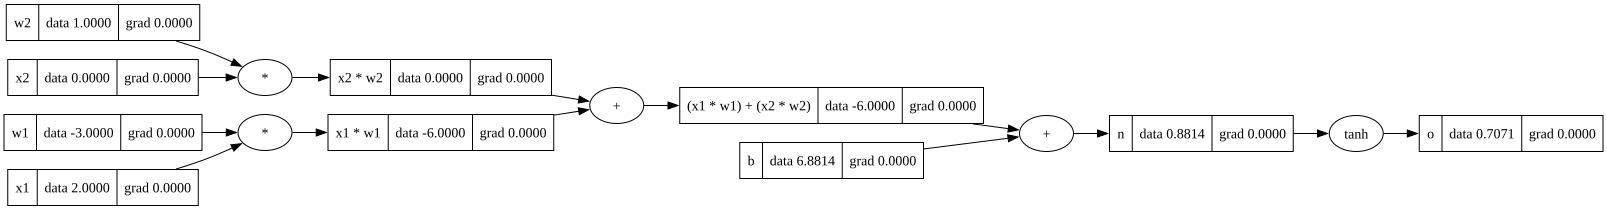

In [11]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1 * w1'
x2w2 = x2 * w2; x2w2.label = 'x2 * w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = '(x1 * w1) + (x2 * w2)'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

draw_dot(o)

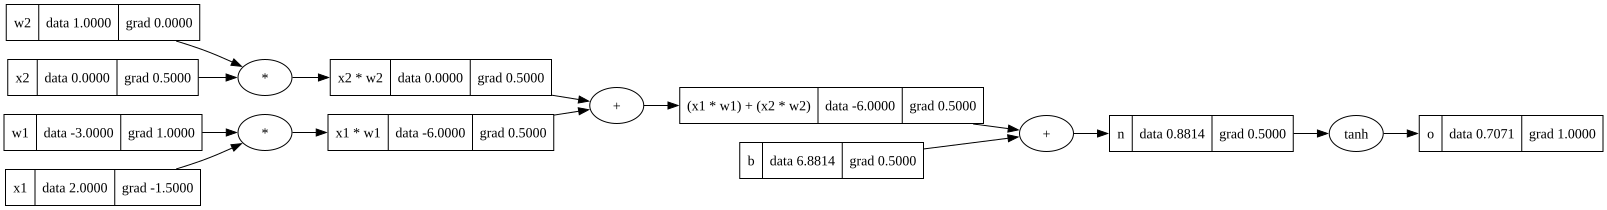

In [12]:
# Manual Backprop
## o = tanh(n)
## do/do = 1
## do/dn = 1 - (tanh(n) ** 2)
## do/db = do/dx1w1x2w2 = do/dn (+ operation)
## do/dx1w1 = do/dx2w2 = do/dx1w1x2w2 (+ operation)
## do/dw1 = x1.data * do/dx1w1; do/dw2 = x2.data * do/dx2w2 (* operation)

o.grad = 1

n.grad = 0.5 # 1 - (o.data ** 2)

x1w1x2w2.grad = 0.5 # n.grad
b.grad = 0.5 # n.grad

x1w1.grad = 0.5 # x1w1x2w2.grad
x2w2.grad = 0.5 # x1w1x2w2.grad

x1.grad = -3.0 * 0.5 # w1.data * x1w1.grad
w1.grad = 2.0 * 0.5 # x1.data * x1w1.grad

x2.grad = 1.0 * 0.5 # w2.data * x2w2.grad
w2.grad = 0.0 * 0.5 # x2.data * x2w2.grad

draw_dot(o)

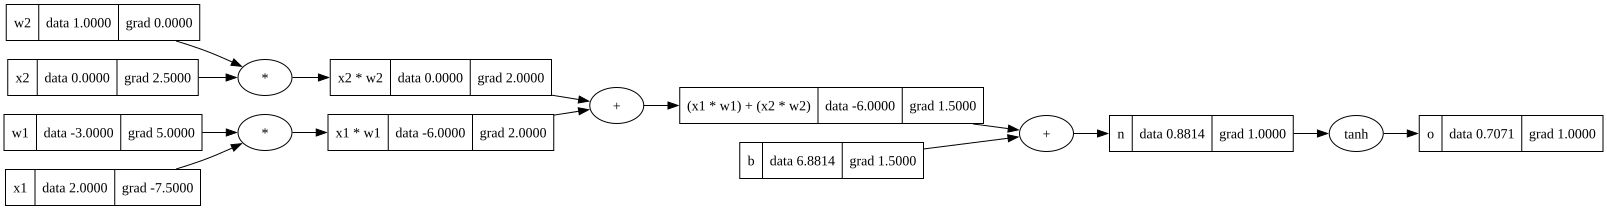

In [13]:
o.backward()

draw_dot(o)

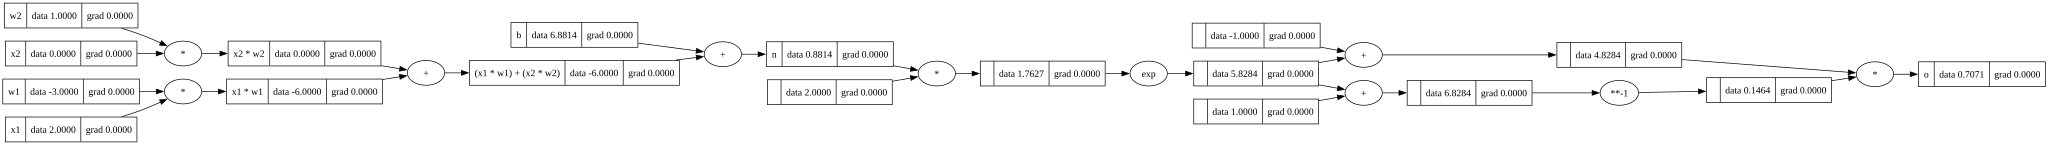

In [14]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1 * w1'
x2w2 = x2 * w2; x2w2.label = 'x2 * w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = '(x1 * w1) + (x2 * w2)'
n = x1w1x2w2 + b; n.label = 'n'

# ----
e = (2*n).exp()
o = (e - 1) / (e + 1); o.label = 'o'
# ----

draw_dot(o)

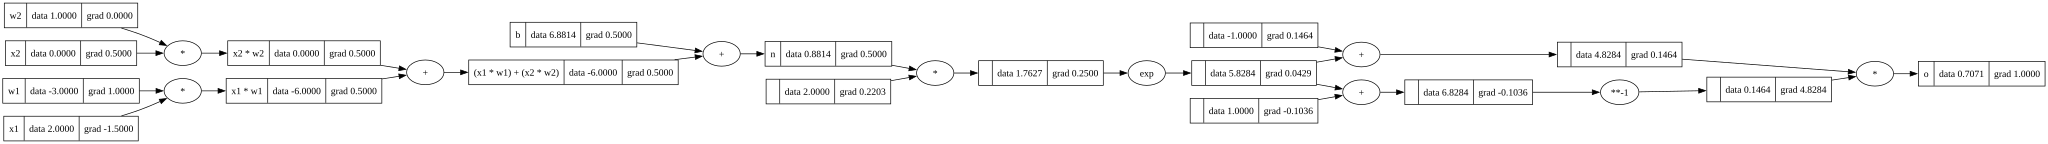

In [15]:
o.backward()
draw_dot(o)

In [16]:
import torch

x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

0.7071066904050358
---
x1 -1.5000003851533106
w1 1.0000002567688737
x2 0.5000001283844369
w2 0.0


In [17]:
class Neuron:
    def __init__(self, n_in):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_in)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        
        return out

    def parameters(self):
        out = self.w + [self.b]
        
        return out

x = [2.0, 3.0]
n = Neuron(2)

n(x)

Value(data=-0.9491057720312057)

In [18]:
class Layer:
    def __init__(self, n_in, n_out):
        self.neurons = [Neuron(n_in) for _ in range(n_out)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        
        return out[0] if len(out) == 1 else out

    def parameters(self):
        out = [p for n in self.neurons for p in n.parameters()]

        return out
        
x = [2.0, 3.0]
l = Layer(2, 1)

l(x)

Value(data=-0.9999102098134355)

In [19]:
class MLP:
    def __init__(self, n_in, n_outs):
        sz = [n_in] + n_outs
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(n_outs))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)

        return x

    def parameters(self):
        out = [p for l in self.layers for p in l.parameters()]

        return out

x = [2.0, 3.0, -1.0]
mlp = MLP(3, [4, 4, 1])

mlp(x)

Value(data=-0.6418241626828954)

In [36]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets

nn = MLP(3, [4, 4, 1])

In [55]:
for k in range(20):

    # forward pass
    y_pred = [nn(x) for x in xs]
    loss = sum((y_t - y_p)**2 for y_t, y_p in zip(ys, y_pred))

    # backward pass
    for p in nn.parameters():
        p.grad = 0.0
    loss.backward()

    # update the parameters
    for p in nn.parameters():
        p.data += -0.1 * p.grad

    print(k, loss.data)

0 0.0007874676396243533
1 0.0007851454380250946
2 0.0007828365030314645
3 0.0007805407224879201
4 0.0007782579854923629
5 0.0007759881823787341
6 0.0007737312046998666
7 0.0007714869452107372
8 0.0007692552978518389
9 0.0007670361577329197
10 0.0007648294211170087
11 0.0007626349854046589
12 0.0007604527491183902
13 0.000758282611887555
14 0.0007561244744332361
15 0.0007539782385535873
16 0.0007518438071092571
17 0.0007497210840091391
18 0.0007476099741963219
19 0.0007455103836342407


In [56]:
[nn(x) for x in xs]

[Value(data=0.9906039564055243),
 Value(data=-0.9883218895681842),
 Value(data=-0.9831607569389363),
 Value(data=0.9846638266201585)]